In [5]:
import deltakit_stim as stim
import sys
sys.modules["stim"] = deltakit_stim 

#### Detector Error Models / DEMs

detector D0
Means: there are no error mechanisms which will flip D0


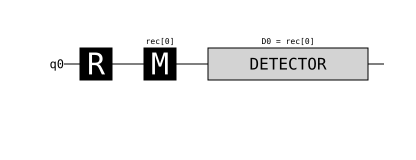

In [10]:
circuit = stim.Circuit("""
R 0
M 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model())
print("Means: there are no error mechanisms which will flip D0")
circuit.diagram("timeline-svg")

error(0.001) D0
Means: an error occurs with 0.001 chance and it flips D0


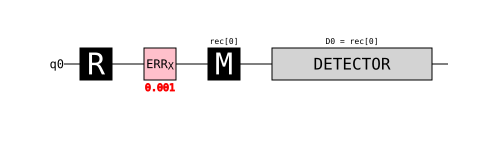

In [4]:
circuit = stim.Circuit("""
R 0
X_ERROR(0.001) 0
M 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model())
print("Means: an error occurs with 0.001 chance and it flips D0")
circuit.diagram("timeline-svg")

error(0.001) D0
Means: an error occurs with 0.001 chance and it flips D0


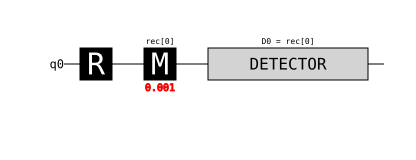

In [ ]:
# Equivalent to above but instead of an X error it's a faulty measurement. Gives same DEM:
circuit = stim.Circuit("""
R 0
M(0.001) 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model())
print("Means: an error occurs with 0.001 chance and it flips D0")
circuit.diagram("timeline-svg")

error(0.001) D0
error(0.001) D1
Means:
     - an error mechanism occurs with 0.001 chance and flips D0
     - an error mechanism occurs with 0.001 chance and flips D0


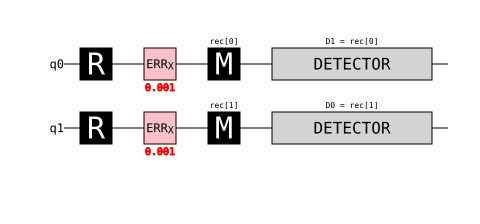

In [7]:
circuit = stim.Circuit("""
R 0 1
X_ERROR(0.001) 0 1
M 0 1
DETECTOR rec[-1]
DETECTOR rec[-2]
""")
print(circuit.detector_error_model())
print("Means:\n     - an error mechanism occurs with 0.001 chance and flips D0\n     - an error mechanism occurs with 0.001 chance and flips D0")
circuit.diagram("timeline-svg")

error(0.002) D0 D1


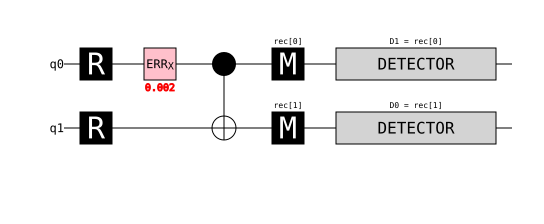

In [30]:
circuit = stim.Circuit("""
R 0 1
X_ERROR(0.002) 0
CNOT 0 1
M 0 1
DETECTOR rec[-1]
DETECTOR rec[-2]
""")
print(circuit.detector_error_model())
circuit.diagram("timeline-svg")

detector D0
Means: there are no error mechanisms which will flip D0. (We know this to be false because leakage from deltakit_stim cause depolarising noise. However, as per the answer that Roland Guichard
relayed in his email: 'No leakage information is emitted into the DEM unless it is heralded (need to add HERALD_LEAKAGE_EVENT)' and the herald must appear 'beofre the measurement it relates to').


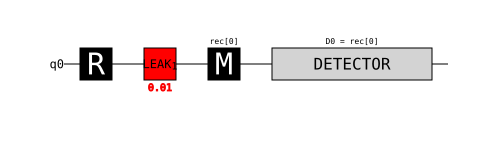

In [27]:
circuit = stim.Circuit("""
R 0
LEAKAGE(0.01) 0
M 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model())
print("Means: there are no error mechanisms which will flip D0. (We know this to be false because leakage from deltakit_stim cause depolarising noise. However, as per the answer that Roland Guichard\nrelayed in his email: 'No leakage information is emitted into the DEM unless it is heralded (need to add HERALD_LEAKAGE_EVENT)' and the herald must appear 'beofre the measurement it relates to').")
circuit.diagram("timeline-svg")

detector D0


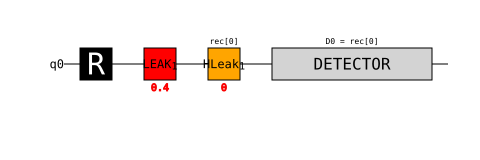

In [ ]:
circuit = stim.Circuit("""
R 0
LEAKAGE(0.3) 0
HERALD_LEAKAGE_EVENT(0) 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model())
circuit.diagram("timeline-svg")

error(0.5) D0 D1


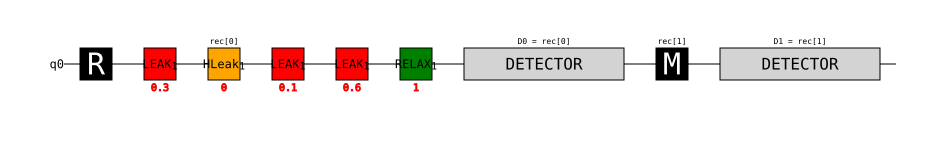

In [29]:
circuit = stim.Circuit('''
R 0
LEAKAGE(0.3) 0
HERALD_LEAKAGE_EVENT() 0
LEAKAGE(0.1) 0
LEAKAGE(0.6) 0
RELAX(1) 0
DETECTOR rec[-1]
M 0
DETECTOR rec[-1]''')
print(circuit.detector_error_model())
circuit.diagram('timeline-svg')

error(0.2) D0


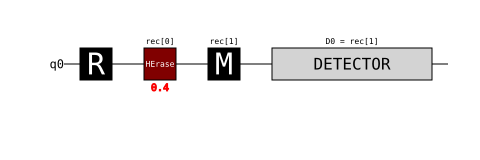

In [32]:
circuit = stim.Circuit("""
R 0
X_ERROR(0.2) 
HERALDED_ERASE(0.4) 0
# DETECTOR rec[-1]
M 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model(approximate_disjoint_errors = True))
circuit.diagram("timeline-svg")

error(0.15) D0
error(0.15) D0 D1 D2

There is a p/2 chance that the error will affect the state and set off the first detector. If the first detector is set off then all of them are.


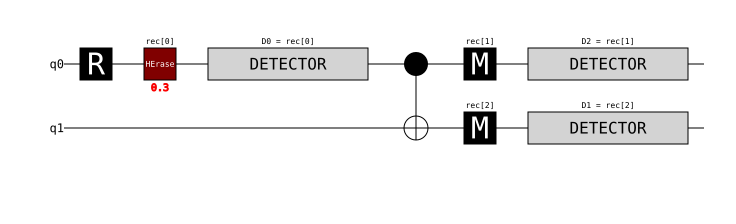

In [6]:
import deltakit_stim as stim
circuit = stim.Circuit("""
R 0 
HERALDED_ERASE(0.3) 0
DETECTOR rec[-1]
CNOT 0 1
M 0 1
DETECTOR rec[-1]
DETECTOR rec[-2]
""")
print(circuit.detector_error_model(approximate_disjoint_errors = True))
print("\nThere is a p/2 chance that the error will affect the state and set off the first detector. If the first detector is set off then all of them are.")
circuit.diagram("timeline-svg")

detector D0


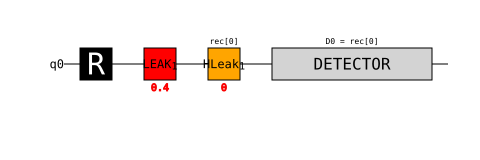

In [18]:
circuit = stim.Circuit("""
R 0 
LEAKAGE(0.4) 0
HERALD_LEAKAGE_EVENT() 0
DETECTOR rec[-1]
""")
print(circuit.detector_error_model(approximate_disjoint_errors = True))
circuit.diagram("timeline-svg")

error(0.15) D0
error(0.15) D0 D1 D2

There is a p/2 chance that the error will affect the state and set off the first detector. If the first detector is set off then all of them are.


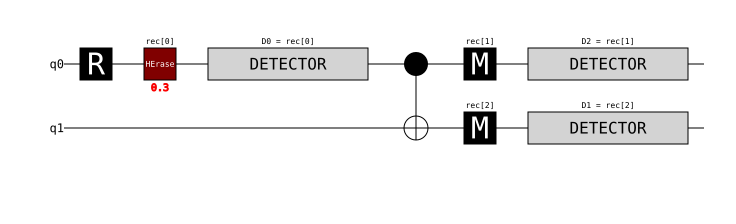

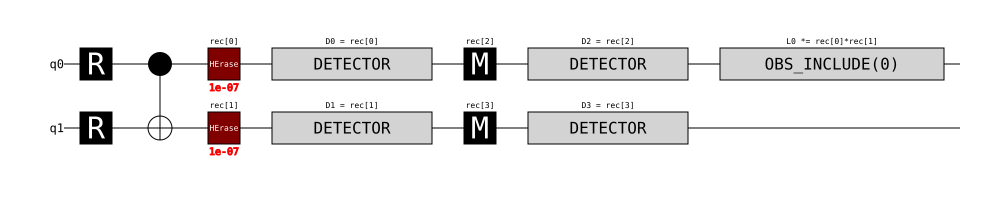

In [ ]:
import deltakit_stim as stim

circuit = stim.Circuit("""
R 0 1
CNOT 0 1
HERALDED_ERASE(1e-7) 0 1
DETECTOR rec[-2]
DETECTOR rec[-1]
M 0 1
DETECTOR rec[-2]
DETECTOR rec[-1]
OBSERVABLE_INCLUDE(0) rec[-4] rec[-3]
""")

circuit.diagram("timeline-svg")